In [94]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [95]:
def load_temp_data(path="./", celsius=True, plot_type=None):
  """
  Function designed to load an process temperature data from a .csv file

  Args:
  path (str): path to the directory of the .csv file
  celsius (bool): designate whether to convert temperatures to celsius or not
  plot_type (str): Specify what type of plot to show

  Returns:
  temp_data (pd.DataFrame): a dataframe of the temperature data
  """

  # 1. Data loading and processing ----------------------------------
  temp_data = pd.read_csv(os.path.join(path, "temperature_data.csv"))
  temp_data = temp_data[["DATE", "TEMP"]]
  temp_data["DATE"] = pd.to_datetime(temp_data["DATE"])
  temp_data = temp_data.sort_values("DATE")
  temp_data = temp_data.set_index("DATE")

  ylabel = "Fahrenheit"

  if celsius:   # Convert to celsius
    temp_data["TEMP"] = round((temp_data["TEMP"] - 32) * 5/9., 1)
    ylabel = "Celsius"


  # 2. Plotting ---------------------------------------------------
  if plot_type == "scatter":  # Scatter plot
    figsize = (12,4)
    plt.figure(figsize=figsize)
    plt.scatter(temp_data.index, temp_data["TEMP"], s=4, alpha=0.3)
    plt.ylabel(ylabel)
    plt.xlabel("Date")
    plt.show()

  elif plot_type == "line":   # Line plot
    figsize = (12,4)
    plt.figure(figsize=figsize)
    plt.plot(temp_data.index, temp_data["TEMP"])
    plt.ylabel(ylabel)
    plt.xlabel("Date")
    plt.show()

  elif plot_type == "hist":    # histogram
    num_bins = int(len(temp_data) ** .5)
    plt.hist(temp_data["TEMP"], bins=num_bins)
    plt.ylabel("Frequency")
    plt.xlabel(ylabel)
    plt.show()

  elif plot_type == "box":     # Box plot
    plt.boxplot(temp_data["TEMP"])
    plt.ylabel(ylabel)
    plt.show()

  else:
    pass

  return temp_data

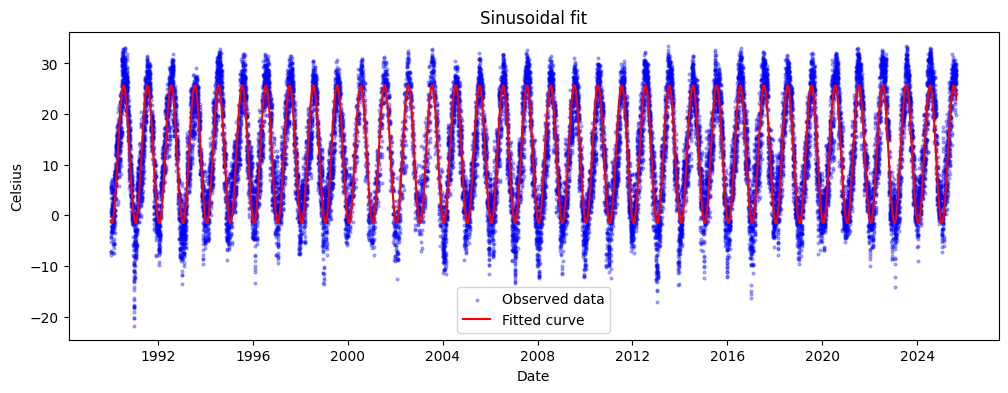

<function __main__.fit_temp_sinusoid.<locals>.<lambda>(x)>

In [116]:
def fit_temp_sinusoid(show_plot=False):

  # 1. Preparing data ----------------------------------------
  temp_data = load_temp_data()

  x = (temp_data.index - temp_data.index.min()).days.to_numpy()
  y = temp_data["TEMP"].to_numpy()

  # 2. Fitting a sinusoid curve to data ----------------------
  def sinusoid(x, A, B, phi, C):
    return A * np.sin(B * x + phi) + C

  A0 = (y.max() - y.min()) / 2
  B0 = 2 * np.pi / 365.25
  phi0 = 0
  C0 = y.mean()

  params, _ = curve_fit(sinusoid, x, y, p0=[A0, B0, phi0, C0])
  A, B, phi, C = params

  fitted_temp = lambda x: sinusoid(x, A, B, phi, C)

  # 3. Plotting ----------------------------------------------
  if show_plot:
    figsize = (12,4)
    plt.figure(figsize=figsize)
    plt.scatter(temp_data.index, y, s=4, alpha=0.3, color="blue", label="Observed data")
    plt.plot(temp_data.index, fitted_temp(x), color="red", label="Fitted curve")
    plt.title("Sinusoidal fit")
    plt.xlabel("Date")
    plt.ylabel("Celsius")
    plt.legend()
    plt.show()

  return fitted_temp

fit_temp_sinusoid(show_plot=True)



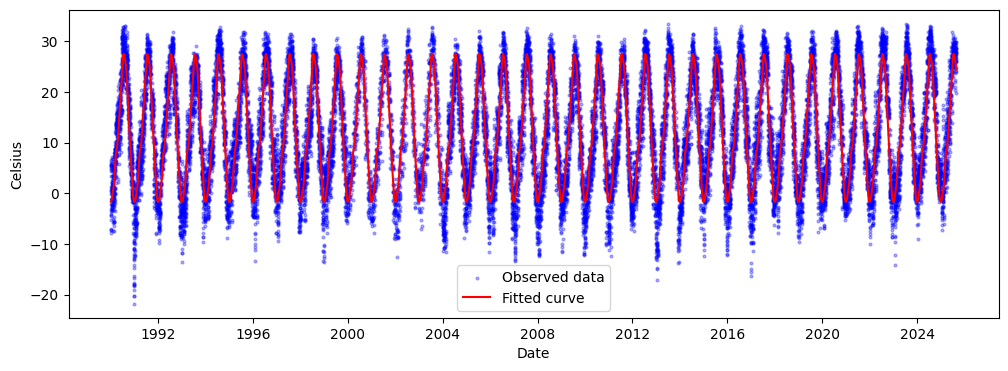

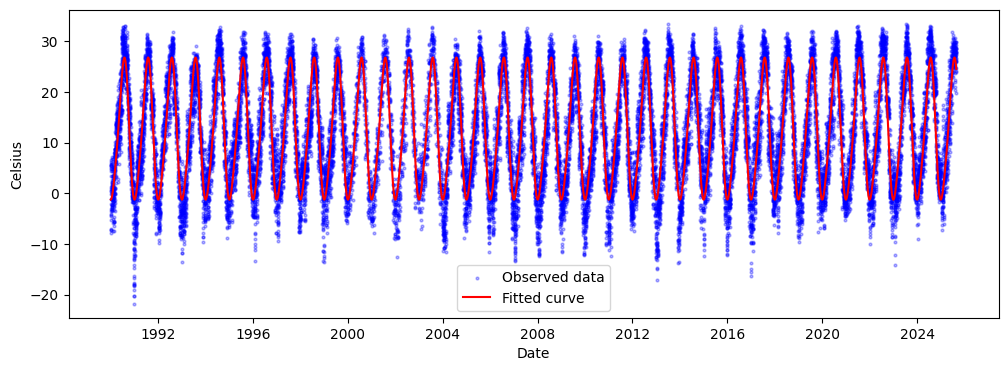

<function __main__.fit_temp_fourier.<locals>.fitted_temp(t)>

In [114]:
def fit_temp_fourier(K=3, show_plot=False):

  # 1. Data preparation ----------------------------------------------
  temp_data = load_temp_data()

  x = (temp_data.index - temp_data.index.min()).days.to_numpy()
  y = temp_data["TEMP"].to_numpy()

  # 2. Fit fourier series --------------------------------------------
  X = [np.ones_like(x)]

  for k in range(1, K+1):
    X.append(np.sin(2*np.pi*k*x/365.25))
    X.append(np.cos(2*np.pi*k*x/365.25))

  X = np.column_stack(X)

  beta, *_ = np.linalg.lstsq(X, y, rcond=None)

  def fitted_temp(t):

    X_eval = [np.ones_like(t)]

    for k in range(1, K+1):
      X_eval.append(np.sin(2*np.pi*k*t/365.25))
      X_eval.append(np.cos(2*np.pi*k*t/365.25))

    X_eval = np.column_stack(X_eval)

    return X_eval @ beta

  if show_plot == True:
    figsize = (12,4)
    plt.figure(figsize=figsize)
    plt.scatter(temp_data.index, y, s=4, alpha=0.3, color="blue", label="Observed data")
    plt.plot(temp_data.index, fitted_temp(x), color="red", label="Fitted curve")
    plt.xlabel("Date")
    plt.ylabel("Celsius")
    plt.legend()
    plt.show()

  return fitted_temp

fitted_temp = fit_temp_fourier(K=10, show_plot=True)
fit_temp_fourier(K=2, show_plot=True)


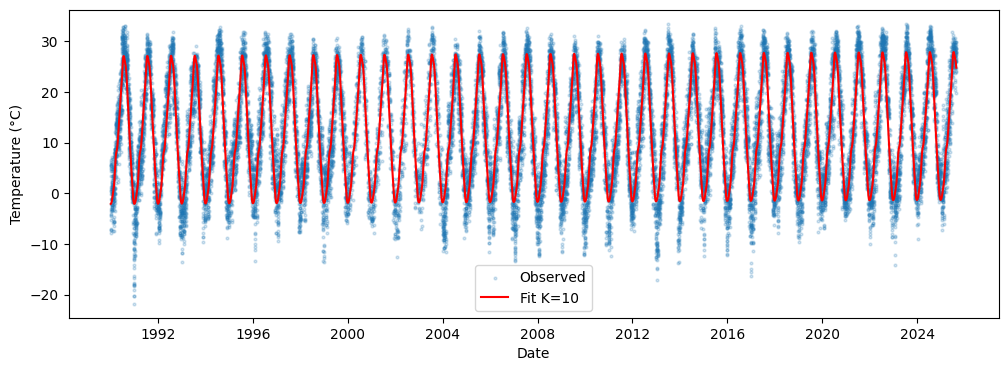

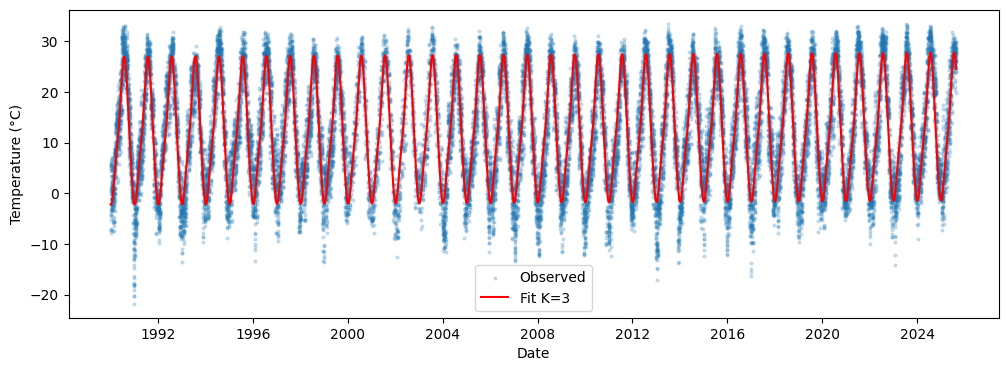

<function __main__.fit_temp_full.<locals>.fitted_temp(t_dates)>

In [117]:
def fit_temp_full(K=3, show_plot=False):

    # Convert dates to numeric days
    temp_data = load_temp_data()

    x = (temp_data.index - temp_data.index.min()).days.to_numpy()
    y = temp_data["TEMP"].to_numpy()

    # Build design matrix: trend + Fourier series
    X = [np.ones_like(x), x]  # intercept + linear trend
    for k in range(1, K+1):
        X.append(np.sin(2*np.pi*k*x/365.25))
        X.append(np.cos(2*np.pi*k*x/365.25))
    X = np.column_stack(X)

    # Least squares fit
    beta, *_ = np.linalg.lstsq(X, y)

    # Fit function
    def fitted_temp(t_dates):
        t = (t_dates - temp_data.index.min()).days.to_numpy()
        X_eval = [np.ones_like(t), t]
        for k in range(1, K+1):
            X_eval.append(np.sin(2*np.pi*k*t/365.25))
            X_eval.append(np.cos(2*np.pi*k*t/365.25))
        X_eval = np.column_stack(X_eval)
        return X_eval @ beta

    if show_plot:
        plt.figure(figsize=(12,4))
        plt.scatter(temp_data.index, y, s=4, alpha=0.2, label="Observed")
        plt.plot(temp_data.index, fitted_temp(temp_data.index), color="red", label=f"Fit K={K}")
        plt.xlabel("Date")
        plt.ylabel("Temperature (°C)")
        plt.legend()
        plt.show()

    return fitted_temp

fitted_temp = fit_temp_full(K=10, show_plot=True)
fit_temp_full(show_plot=True)
